<a href="https://colab.research.google.com/github/Moaz-Sakrr/Weapon-vs-Umbrella-Detection/blob/main/Weapon_vs_Umbrella_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics -q

import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
base_path = '/content/dataset'
images_path = os.path.join(base_path, 'images')

all_images = [os.path.join(images_path, f) for f in os.listdir(images_path) if f.endswith('.JPG')]

random.seed(42)
random.shuffle(all_images)

split_idx = int(len(all_images) * 0.8)

train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

with open('/content/train.txt', 'w') as f:
    f.write('\n'.join(train_images))

with open('/content/val.txt', 'w') as f:
    f.write('\n'.join(val_images))

In [17]:
model = YOLO('yolov8l.pt')

results = model.train(
    data='/content/dataset/data.yaml',
    epochs=25,
    imgsz=640,
    device=0
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,


image 1/1 /content/dataset/images/person_rifle_vs_umbrella_080.JPG: 640x448 1 person, 1 weapon, 46.9ms
Speed: 3.2ms preprocess, 46.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 448)


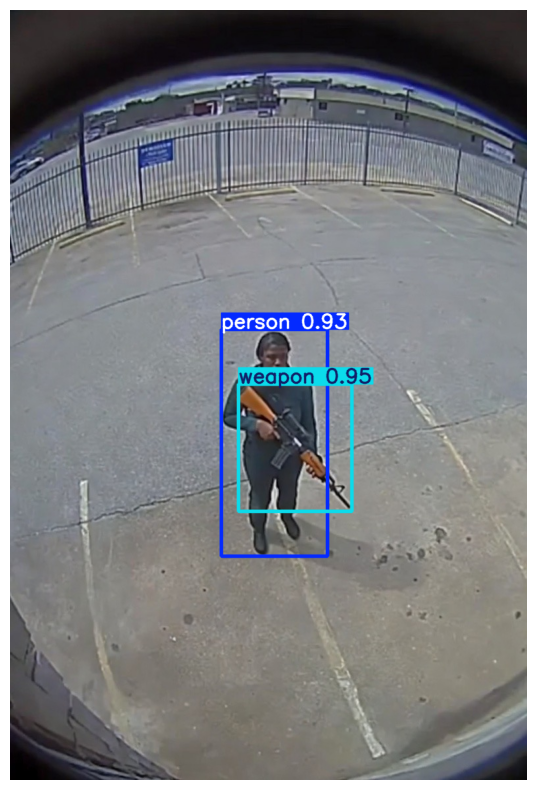

In [23]:
model_path = '/content/runs/detect/train5/weights/best.pt'

model = YOLO(model_path)

image_path = '/content/dataset/images/person_rifle_vs_umbrella_080.JPG'

results = model.predict(source=image_path, conf=0.5)

for r in results:
    im_array = r.plot()
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,10))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.show()

In [24]:
!pip install gradio ultralytics -q

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


In [49]:
import gradio as gr
from ultralytics import YOLO
import cv2

# Ensure model is loaded
model = YOLO('/content/runs/detect/train5/weights/best.pt')

def detect_image(image):
    results = model(image)
    annotated = results[0].plot()
    return annotated

# Gradio interface setup with horizontal layout
with gr.Blocks() as demo:
    gr.Markdown("# **Weapon vs Umbrella Detection**")

    with gr.Tab("Image"):
        with gr.Row():
            img_input = gr.Image(type="numpy", label="Input Image")
            img_output = gr.Image(label="Detection Result")

        btn = gr.Button("Detect", variant="primary")
        btn.click(detect_image, inputs=img_input, outputs=img_output)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2117daef01c80c1321.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
